<a href="https://colab.research.google.com/github/feyzacelik/AI-Driven-Solar-Power-Generation-Forecasting-/blob/main/Solar_Power_Forecasting_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Driven Solar Power Generation Forecasting for Grid Stability


### Project Members
- Feyza Çelik – 25069605  
- Gönül Saraç  
- Özge Önal  
- Odil Mamasaliev  

The study focuses on forecasting solar power generation using environmental sensor data, engineered time-series features, and an industrial demand proxy. The main goal is to support grid stability by predicting renewable energy output and comparing it with industrial energy demand.

# Overview

This project aims to predict solar power generation fluctuations using micro-climate data and industrial demand profiles. Solar energy is highly weather-dependent, and sudden changes in irradiation or temperature can cause power generation instability. By using machine learning models, short-term solar power output can be forecasted more accurately.

The project also integrates an industrial demand proxy to simulate how renewable energy supply can be compared with high-consumption industrial electricity demand. This makes the study more relevant for smart grid decision-making and load balancing.


# Key Objectives

The main objectives of this project are:

- To forecast solar AC power generation using environmental and time-series features.
- To analyze the relationship between irradiation, temperature, and solar power output.
- To integrate an industrial demand proxy for smart grid stability analysis.
- To compare different machine learning models.
- To refine the model using hyperparameter tuning and time-series cross-validation.
- To prepare the final model for deployment using model serialization and API integration concepts.


# PART A – MODEL REFINEMENT

This section focuses on improving the forecasting model by applying data preparation, feature engineering, model evaluation, model comparison, hyperparameter tuning, cross-validation, and feature selection.


## 1. Setup and Required Libraries

In this step, the required Python libraries are imported. These libraries are used for data processing, visualization, model training, model evaluation, and model deployment.

In [45]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 2. Data Preparation and Feature Engineering

The solar power generation dataset and weather sensor dataset are loaded and merged based on the timestamp. The generation data includes AC power and DC power values, while the weather sensor data includes ambient temperature, module temperature, and irradiation.

Additional features are created to improve model performance:
- `temp_diff`: Difference between module temperature and ambient temperature.
- `hour`: Hour of the day.
- `dayofweek`: Day of the week.
- `month`: Month information.
- `power_lag_1h`: Previous one-hour AC power value.
- `industrial_demand_proxy`: Simulated industrial demand profile for smart grid analysis.

### 2.1. Data Loading

In this step, the generation and weather sensor datasets are loaded into Python. The first rows of both datasets are displayed to check their structure.

In [46]:
generation_df = pd.read_csv("/content/Plant_1_Generation_Data.csv")
weather_df = pd.read_csv("/content/Plant_1_Weather_Sensor_Data.csv")

print("Generation Data Shape:", generation_df.shape)
print("Weather Data Shape:", weather_df.shape)

display(generation_df.head())
display(weather_df.head())

Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


### 2.2. Data Merging Based on Timestamp

The generation and weather sensor datasets are merged using the `DATE_TIME` column. Since the generation dataset contains multiple inverter/source records for the same timestamp, the power values are aggregated by timestamp before merging. Weather variables are also aggregated by timestamp using their mean values.

In [47]:
generation_df["DATE_TIME"] = pd.to_datetime(generation_df["DATE_TIME"], errors="coerce")
weather_df["DATE_TIME"] = pd.to_datetime(weather_df["DATE_TIME"], errors="coerce")

generation_df = generation_df.dropna(subset=["DATE_TIME"])
weather_df = weather_df.dropna(subset=["DATE_TIME"])

gen_agg = generation_df.groupby("DATE_TIME", as_index=False).agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum"
})

weather_agg = weather_df.groupby("DATE_TIME", as_index=False).agg({
    "AMBIENT_TEMPERATURE": "mean",
    "MODULE_TEMPERATURE": "mean",
    "IRRADIATION": "mean"
})

df = pd.merge(gen_agg, weather_agg, on="DATE_TIME", how="inner")
df = df.sort_values("DATE_TIME").reset_index(drop=True)

display(df.head())
print("Merged Data Shape:", df.shape)

,DATE_TIME,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


Merged Data Shape: (3157, 6)


### 2.3. Feature Engineering

Several additional variables were created to improve the forecasting performance of the model. The `temp_diff` variable represents the difference between module and ambient temperature. Time-based variables such as `hour`, `dayofweek`, and `month` were extracted from the timestamp. A one-hour lag feature was also created to represent recent historical solar power behavior.

In [48]:
df["temp_diff"] = df["MODULE_TEMPERATURE"] - df["AMBIENT_TEMPERATURE"]
df["hour"] = df["DATE_TIME"].dt.hour
df["dayofweek"] = df["DATE_TIME"].dt.dayofweek
df["month"] = df["DATE_TIME"].dt.month

df["power_lag_1h"] = df["AC_POWER"].shift(4)

df = df.dropna().reset_index(drop=True)

display(df.head())
print("Dataset Shape After Feature Engineering:", df.shape)
print(df.columns)

,DATE_TIME,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,temp_diff,hour,dayofweek,month,power_lag_1h
0,2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0,-2.456103,1,4,5,0.0
1,2020-05-15 01:15:00,0.0,0.0,24.536092,21.968571,0.0,-2.567521,1,4,5,0.0
2,2020-05-15 01:30:00,0.0,0.0,24.638674,22.352926,0.0,-2.285748,1,4,5,0.0
3,2020-05-15 01:45:00,0.0,0.0,24.873022,23.160919,0.0,-1.712103,1,4,5,0.0
4,2020-05-15 02:00:00,0.0,0.0,24.936930,23.026113,0.0,-1.910817,2,4,5,0.0


Dataset Shape After Feature Engineering: (3153, 11)
Index(['DATE_TIME', 'DC_POWER', 'AC_POWER', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'temp_diff', 'hour', 'dayofweek',
       'month', 'power_lag_1h'],
      dtype='object')


## 3. Industrial Demand Proxy Methodology

In this project, the industrial demand variable was used as a proxy to represent the energy consumption behavior of a high-demand industrial facility. Since the solar plant dataset does not include real factory load measurements, an industrial demand profile was created as an external reference variable.

The purpose of this proxy is not to claim that the solar plant and the industrial facility belong to the same physical site. Instead, the proxy is used to simulate a realistic smart grid scenario where renewable energy generation must be compared with industrial electricity demand.

The industrial demand proxy was generated based on typical working-hour electricity consumption patterns. Demand is assumed to be higher during working hours, moderate during transition hours, and lower during night hours. This allows the project to go beyond standard solar power forecasting and examine the relationship between renewable energy supply and industrial demand.

Since the demand variable is a proxy rather than directly measured factory load data, the results should be interpreted as a hybrid forecasting framework rather than a fully deployed industrial grid system.

In [49]:
def industrial_demand_pattern(hour):
    if 8 <= hour <= 18:
        return 1.00
    elif 6 <= hour < 8 or 18 < hour <= 22:
        return 0.75
    else:
        return 0.45

df["industrial_demand_proxy"] = df["hour"].apply(industrial_demand_pattern)

average_power = df["AC_POWER"].mean()
df["industrial_demand_proxy"] = df["industrial_demand_proxy"] * average_power

display(df[["DATE_TIME", "AC_POWER", "hour", "industrial_demand_proxy"]].head(10))
print("Industrial demand proxy added successfully.")

,DATE_TIME,AC_POWER,hour,industrial_demand_proxy
0,2020-05-15 01:00:00,0.0,1,3021.001427
1,2020-05-15 01:15:00,0.0,1,3021.001427
2,2020-05-15 01:30:00,0.0,1,3021.001427
3,2020-05-15 01:45:00,0.0,1,3021.001427
4,2020-05-15 02:00:00,0.0,2,3021.001427
5,2020-05-15 02:15:00,0.0,2,3021.001427
6,2020-05-15 02:30:00,0.0,2,3021.001427
7,2020-05-15 02:45:00,0.0,2,3021.001427
8,2020-05-15 03:00:00,0.0,3,3021.001427
9,2020-05-15 03:15:00,0.0,3,3021.001427


Industrial demand proxy added successfully.


## 4. Exploratory Data Analysis (EDA) & Feature Correlation

In this section, we analyze the statistical relationships between environmental variables and solar power output. Understanding these correlations is important for feature selection and model refinement.

- **Irradiation vs. Power:** To confirm the direct impact of solar intensity on AC/DC power output.
- **Thermal Impact:** To visualize how module temperature and temperature difference correlate with possible efficiency losses.
- **Industrial Integration:** To observe the relationship between the industrial demand proxy and solar generation timing.

A correlation heatmap is used to quantify these relationships. A value closer to `+1.00` indicates a strong positive relationship, while a value closer to `-1.00` indicates a strong negative relationship.

,AC_POWER,DC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,temp_diff,industrial_demand_proxy,hour,power_lag_1h
AC_POWER,1.000000,0.999997,0.726010,0.960989,0.995861,0.977748,0.696813,0.015683,0.878839
DC_POWER,0.999997,1.000000,0.725810,0.960917,0.995954,0.977726,0.696270,0.015694,0.878693
AMBIENT_TEMPERATURE,0.726010,0.725810,1.000000,0.853294,0.721961,0.743752,0.758108,0.324412,0.825957
MODULE_TEMPERATURE,0.960989,0.960917,0.853294,1.000000,0.961399,0.983192,0.750481,0.101202,0.913889
IRRADIATION,0.995861,0.995954,0.721961,0.961399,1.000000,0.979693,0.682101,0.013143,0.870319
temp_diff,0.977748,0.977726,0.743752,0.983192,0.979693,1.000000,0.696646,0.016148,0.882372
industrial_demand_proxy,0.696813,0.696270,0.758108,0.750481,0.682101,0.696646,1.000000,0.426363,0.723607
hour,0.015683,0.015694,0.324412,0.101202,0.013143,0.016148,0.426363,1.000000,0.132039
power_lag_1h,0.878839,0.878693,0.825957,0.913889,0.870319,0.882372,0.723607,0.132039,1.000000


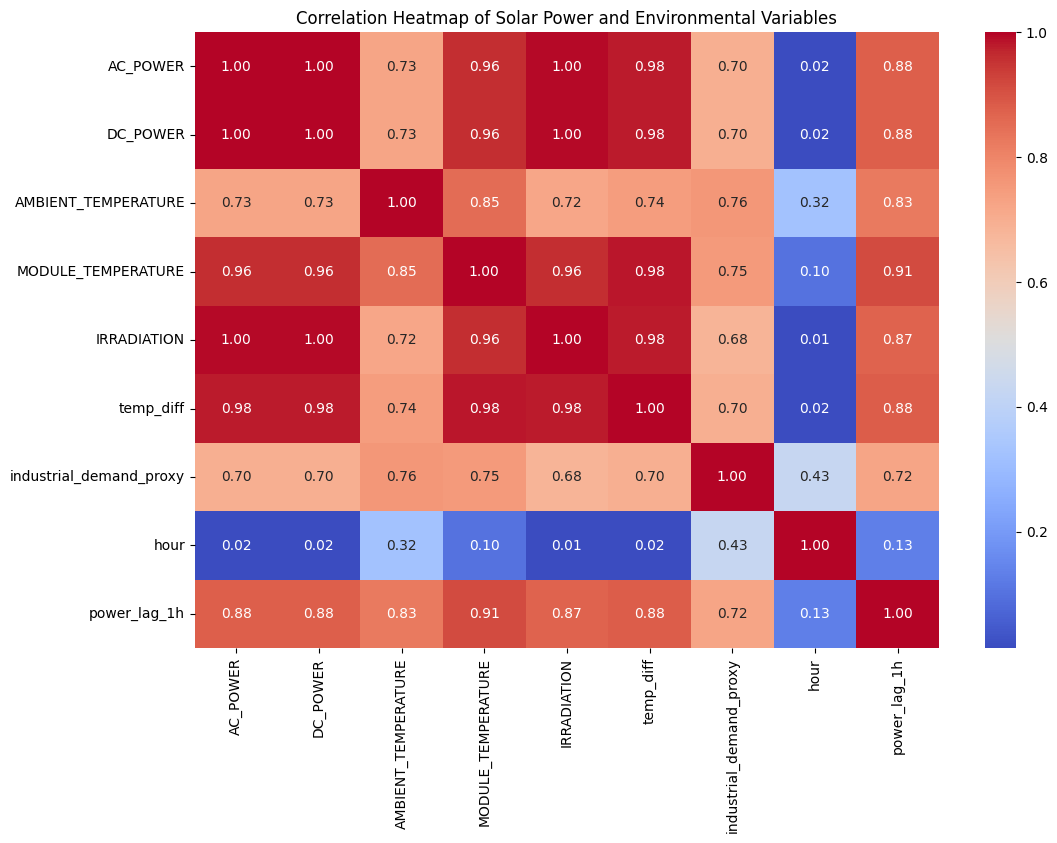

In [50]:
corr_cols = [
    "AC_POWER",
    "DC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "temp_diff",
    "industrial_demand_proxy",
    "hour",
    "power_lag_1h"
]

correlation_matrix = df[corr_cols].corr()

display(correlation_matrix)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Solar Power and Environmental Variables")
plt.show()

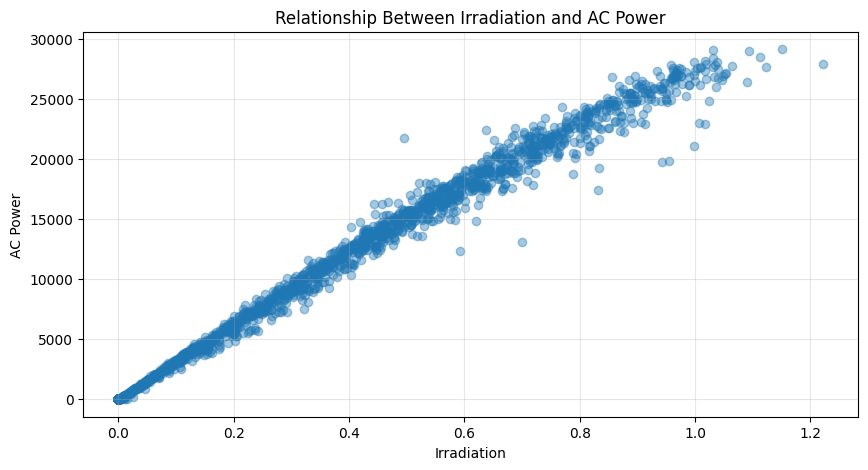

In [51]:
plt.figure(figsize=(10, 5))
plt.scatter(df["IRRADIATION"], df["AC_POWER"], alpha=0.4)
plt.title("Relationship Between Irradiation and AC Power")
plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.grid(alpha=0.3)
plt.show()

## 5. Initial Model: XGBoost Training

XGBoost Regressor was selected as the initial forecasting model because it performs well on structured numerical datasets and can capture non-linear relationships between weather conditions, time-based variables, industrial demand proxy, and solar power output.

A chronological 80/20 train-test split was used instead of a random split. This is important because the dataset has a time-series structure, and future observations should not be used to train a model that predicts earlier values.

In [52]:
features = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "temp_diff",
    "industrial_demand_proxy",
    "hour",
    "dayofweek",
    "month",
    "power_lag_1h"
]

target = "AC_POWER"

X = df[features]
y = df[target]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (2522, 9)
Test set size: (631, 9)


In [53]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print("Initial XGBoost Model Performance")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"R2 Score: {xgb_r2:.4f}")

Initial XGBoost Model Performance
RMSE: 481.74
MAE: 232.18
R2 Score: 0.9963


## 6. Model Evaluation

The initial model was evaluated using RMSE, MAE, and R² Score. RMSE gives higher penalty to large errors, MAE shows the average absolute prediction error, and R² Score indicates how much of the variation in solar power output is explained by the model.

,DATE_TIME,Actual AC Power,Predicted AC Power
2522,2020-06-11 09:45:00,10287.671429,9919.464844
2523,2020-06-11 10:00:00,11091.971429,10994.058594
2524,2020-06-11 10:15:00,12068.066071,11492.098633
2525,2020-06-11 10:30:00,12320.907143,11685.632812
2526,2020-06-11 10:45:00,12771.435714,12011.495117


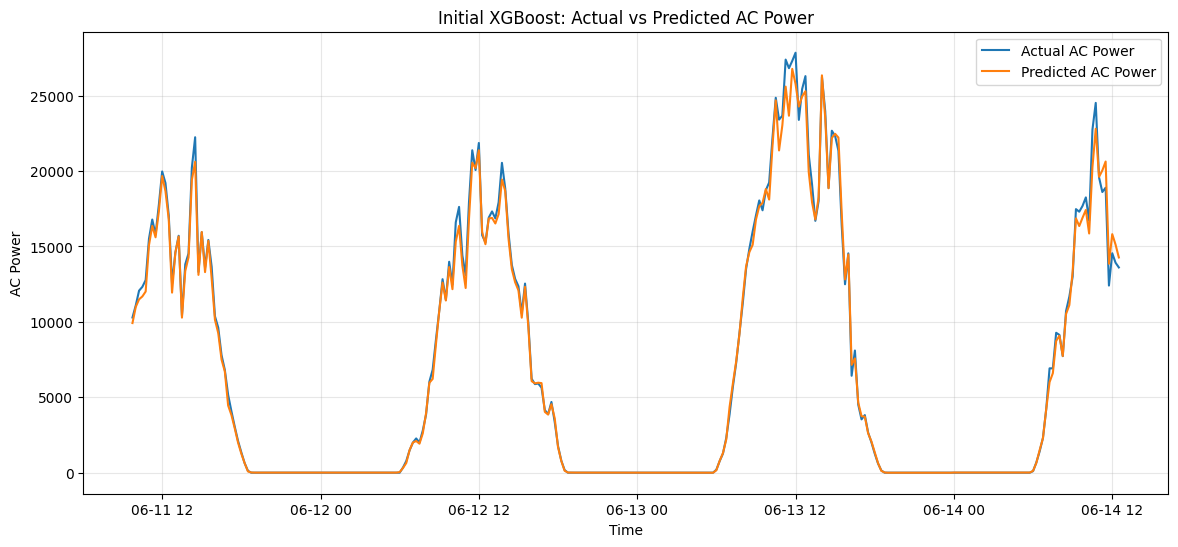

In [54]:
results = pd.DataFrame({
    "DATE_TIME": df["DATE_TIME"].iloc[split_index:],
    "Actual AC Power": y_test.values,
    "Predicted AC Power": xgb_preds
})

display(results.head())

plt.figure(figsize=(14, 6))
plt.plot(results["DATE_TIME"].iloc[:300], results["Actual AC Power"].iloc[:300], label="Actual AC Power")
plt.plot(results["DATE_TIME"].iloc[:300], results["Predicted AC Power"].iloc[:300], label="Predicted AC Power")
plt.title("Initial XGBoost: Actual vs Predicted AC Power")
plt.xlabel("Time")
plt.ylabel("AC Power")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Model Comparison

To evaluate the performance of XGBoost more objectively, two comparison models were added: Linear Regression and Random Forest Regressor. Linear Regression is used as a simple baseline model, while Random Forest is used as a non-linear ensemble model. These models help demonstrate whether the selected XGBoost approach provides competitive forecasting performance.

In [55]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

display(model_comparison)

,Model,RMSE,MAE,R2 Score
0,Linear Regression,701.988588,434.908346,0.992245
1,Random Forest,501.893198,243.017152,0.996036
2,XGBoost,481.735118,232.182830,0.996348


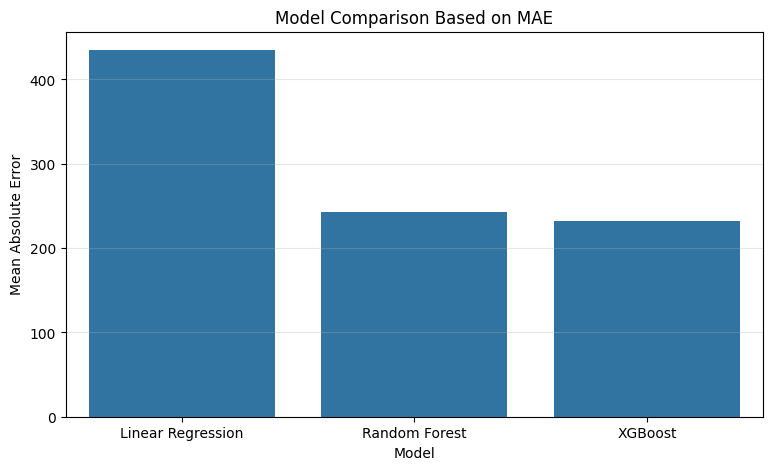

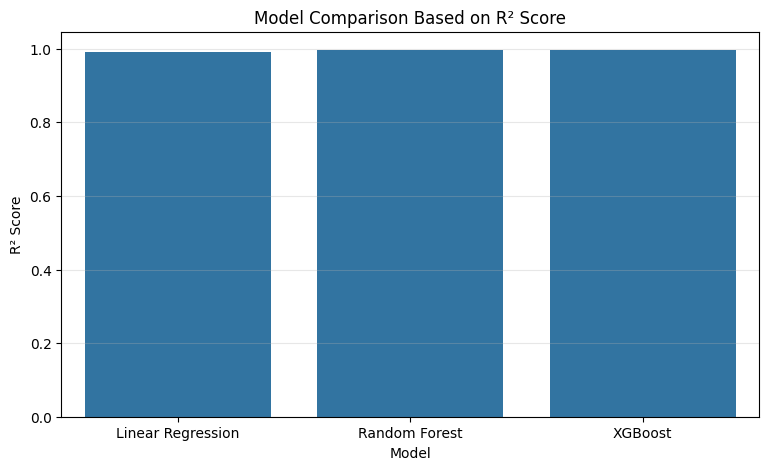

In [56]:
plt.figure(figsize=(9, 5))
sns.barplot(data=model_comparison, x="Model", y="MAE")
plt.title("Model Comparison Based on MAE")
plt.ylabel("Mean Absolute Error")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=model_comparison, x="Model", y="R2 Score")
plt.title("Model Comparison Based on R² Score")
plt.ylabel("R² Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. Hyperparameter Tuning

Hyperparameter tuning was applied to improve the XGBoost model. GridSearchCV was used together with TimeSeriesSplit so that the time order of observations was preserved during validation. The tested parameters include the number of estimators, tree depth, and learning rate.

In [57]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2]
}

tscv_tuning = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv_tuning,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best CV MAE: 330.9384113139734


In [58]:
tuned_xgb_model = grid_search.best_estimator_

tuned_xgb_preds = tuned_xgb_model.predict(X_test)

tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_preds))
tuned_xgb_mae = mean_absolute_error(y_test, tuned_xgb_preds)
tuned_xgb_r2 = r2_score(y_test, tuned_xgb_preds)

print("Tuned XGBoost Model Performance")
print(f"RMSE: {tuned_xgb_rmse:.2f}")
print(f"MAE: {tuned_xgb_mae:.2f}")
print(f"R2 Score: {tuned_xgb_r2:.4f}")

Tuned XGBoost Model Performance
RMSE: 467.51
MAE: 230.13
R2 Score: 0.9966


## 9. Time-Series Cross-Validation

A standard random cross-validation method is not suitable for time-series data because it can mix past and future observations. Therefore, TimeSeriesSplit was applied to validate whether the model can consistently predict future solar power output based on past observations.

In [59]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    cv_model = XGBRegressor(
        n_estimators=grid_search.best_params_["n_estimators"],
        max_depth=grid_search.best_params_["max_depth"],
        learning_rate=grid_search.best_params_["learning_rate"],
        random_state=42
    )

    cv_model.fit(X_train_cv, y_train_cv)
    cv_preds = cv_model.predict(X_test_cv)

    fold_rmse = np.sqrt(mean_squared_error(y_test_cv, cv_preds))
    fold_mae = mean_absolute_error(y_test_cv, cv_preds)
    fold_r2 = r2_score(y_test_cv, cv_preds)

    cv_results.append({
        "Fold": fold,
        "RMSE": fold_rmse,
        "MAE": fold_mae,
        "R2 Score": fold_r2
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

print("Average RMSE:", cv_results_df["RMSE"].mean())
print("Average MAE:", cv_results_df["MAE"].mean())
print("Average R2 Score:", cv_results_df["R2 Score"].mean())

,Fold,RMSE,MAE,R2 Score
0,1,703.175086,347.109040,0.994658
1,2,718.670453,328.534384,0.993200
2,3,920.624487,449.969027,0.988149
3,4,772.767068,320.004310,0.991477
4,5,507.010880,239.839315,0.996084


Average RMSE: 724.4495948503012
Average MAE: 337.09121512360394
Average R2 Score: 0.9927134710640473


## 10. Feature Importance and Feature Selection

Feature importance analysis was used to identify the most influential variables in the tuned XGBoost model. This step supports feature selection by showing which variables contribute most to the prediction of solar power output.

,0
IRRADIATION,0.987209
month,0.004581
industrial_demand_proxy,0.001629
dayofweek,0.001306
temp_diff,0.001265
hour,0.001141
MODULE_TEMPERATURE,0.001019
power_lag_1h,0.001006
AMBIENT_TEMPERATURE,0.000843


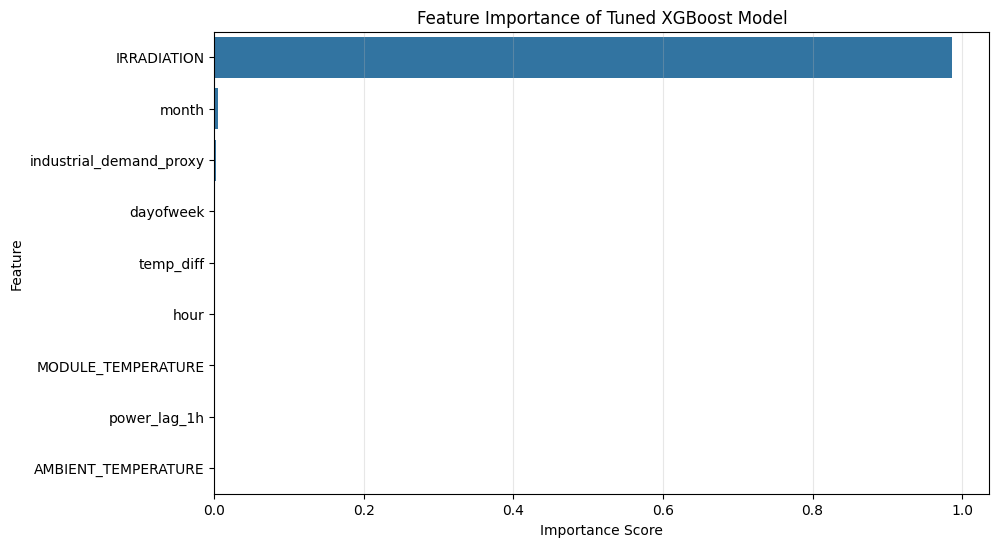

In [60]:
feature_importance = pd.Series(
    tuned_xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance of Tuned XGBoost Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 11. Residual Analysis

Residual analysis was conducted to understand the difference between actual and predicted solar power generation. If the residuals are centered around zero, it indicates that the model does not systematically overestimate or underestimate solar output. This analysis helps evaluate whether the model errors are acceptable for short-term grid stability applications.

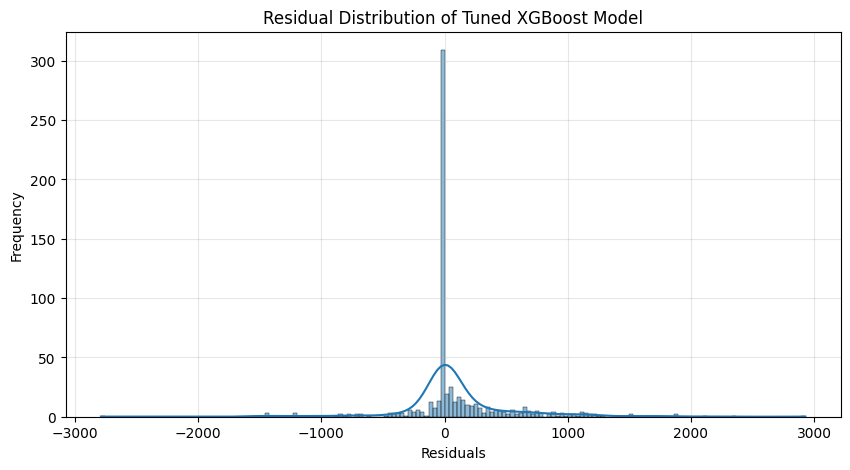

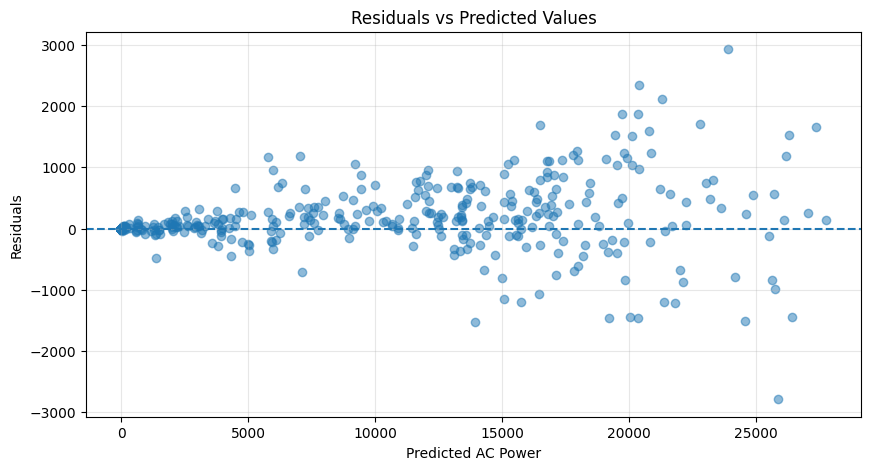

In [61]:
residuals = y_test - tuned_xgb_preds

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution of Tuned XGBoost Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(tuned_xgb_preds, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted AC Power")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)
plt.show()

# PART B – TEST SUBMISSION

This section presents the application of the final refined model on the test set. The test set represents the most recent 20% of the dataset, which simulates a real forecasting scenario where the model is trained on past observations and tested on future unseen data.

The final model used in this section is the tuned XGBoost model obtained after hyperparameter tuning and time-series validation.

## 12. Test Data Preparation

The test data was prepared using the same feature set used during model training. Since this is a time-series forecasting problem, the test set was selected chronologically instead of randomly. This prevents data leakage and makes the evaluation closer to a real-world forecasting scenario.

,Dataset Part,Number of Records,Percentage
0,Training Set,2522,79.99
1,Test Set,631,20.01


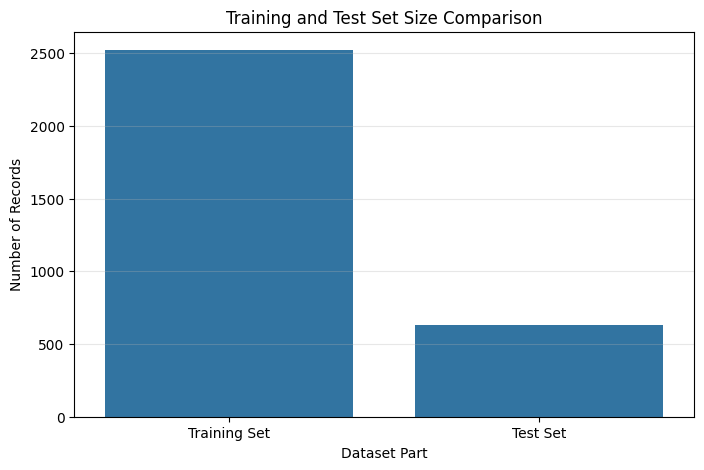

In [62]:
test_data_summary = pd.DataFrame({
    "Dataset Part": ["Training Set", "Test Set"],
    "Number of Records": [len(X_train), len(X_test)],
    "Percentage": [
        round(len(X_train) / len(X) * 100, 2),
        round(len(X_test) / len(X) * 100, 2)
    ]
})

display(test_data_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=test_data_summary, x="Dataset Part", y="Number of Records")
plt.title("Training and Test Set Size Comparison")
plt.ylabel("Number of Records")
plt.xlabel("Dataset Part")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 13. Final Model Application on Test Set

The tuned XGBoost model was selected as the final model and applied to the chronological test set. The model generates predicted AC power values based on environmental conditions, time-based variables, lag features, and the industrial demand proxy.

In [63]:
final_model = tuned_xgb_model

final_test_predictions = final_model.predict(X_test)

test_results = pd.DataFrame({
    "DATE_TIME": df["DATE_TIME"].iloc[split_index:].values,
    "Actual AC Power": y_test.values,
    "Predicted AC Power": final_test_predictions
})

display(test_results.head(10))

,DATE_TIME,Actual AC Power,Predicted AC Power
0,2020-06-11 09:45:00,10287.671429,9916.271484
1,2020-06-11 10:00:00,11091.971429,10939.126953
2,2020-06-11 10:15:00,12068.066071,11552.998047
3,2020-06-11 10:30:00,12320.907143,11691.333008
4,2020-06-11 10:45:00,12771.435714,12075.508789
5,2020-06-11 11:00:00,15504.928571,15065.155273
6,2020-06-11 11:15:00,16784.860714,16353.753906
7,2020-06-11 11:30:00,15787.112500,15629.233398
8,2020-06-11 11:45:00,17764.082143,17122.876953
9,2020-06-11 12:00:00,19972.937500,19551.318359


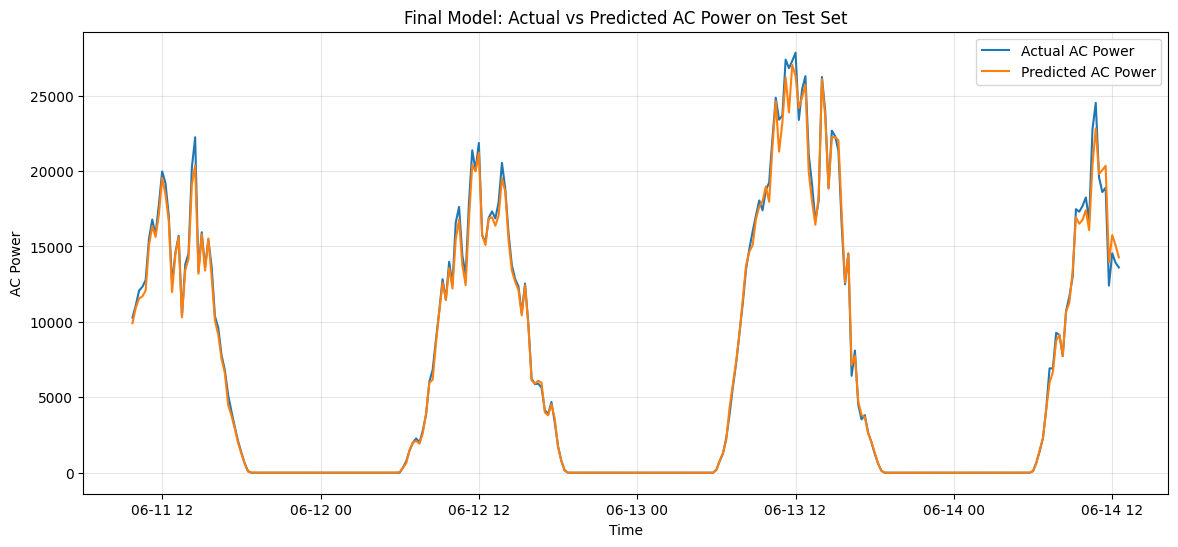

In [64]:
plt.figure(figsize=(14, 6))
plt.plot(test_results["DATE_TIME"].iloc[:300], test_results["Actual AC Power"].iloc[:300], label="Actual AC Power")
plt.plot(test_results["DATE_TIME"].iloc[:300], test_results["Predicted AC Power"].iloc[:300], label="Predicted AC Power")
plt.title("Final Model: Actual vs Predicted AC Power on Test Set")
plt.xlabel("Time")
plt.ylabel("AC Power")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Test Metrics and Results

The final model was evaluated on the test set using RMSE, MAE, and R² Score. These metrics provide a clear understanding of the model's forecasting accuracy on unseen future data.

- **RMSE** measures the overall prediction error and gives higher penalty to large errors.
- **MAE** represents the average absolute difference between actual and predicted values.
- **R² Score** shows how much of the variation in solar power output is explained by the model.

In [65]:
final_test_rmse = np.sqrt(mean_squared_error(y_test, final_test_predictions))
final_test_mae = mean_absolute_error(y_test, final_test_predictions)
final_test_r2 = r2_score(y_test, final_test_predictions)

test_metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R2 Score"],
    "Value": [final_test_rmse, final_test_mae, final_test_r2]
})

display(test_metrics)

,Metric,Value
0,RMSE,467.510463
1,MAE,230.134612
2,R2 Score,0.996560


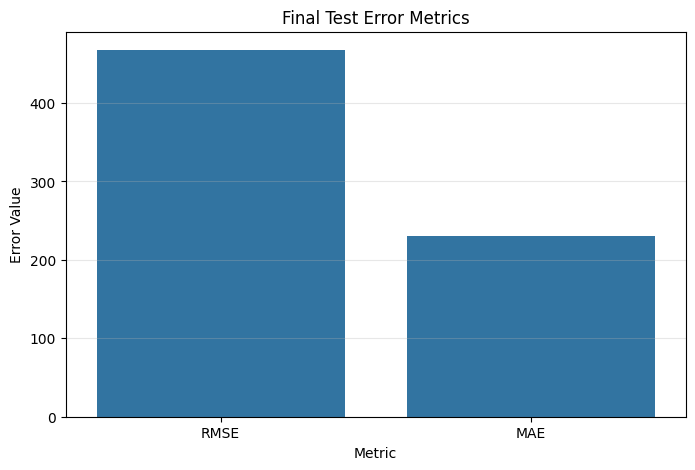

In [66]:
metrics_for_plot = test_metrics[test_metrics["Metric"].isin(["RMSE", "MAE"])]

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_for_plot, x="Metric", y="Value")
plt.title("Final Test Error Metrics")
plt.ylabel("Error Value")
plt.xlabel("Metric")
plt.grid(axis="y", alpha=0.3)
plt.show()

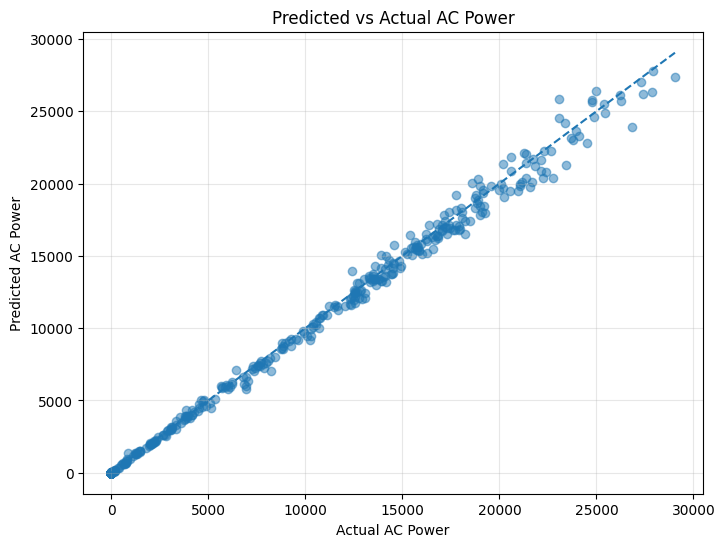

In [67]:
plt.figure(figsize=(8, 6))
plt.scatter(test_results["Actual AC Power"], test_results["Predicted AC Power"], alpha=0.5)
plt.plot(
    [test_results["Actual AC Power"].min(), test_results["Actual AC Power"].max()],
    [test_results["Actual AC Power"].min(), test_results["Actual AC Power"].max()],
    linestyle="--"
)
plt.title("Predicted vs Actual AC Power")
plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.grid(alpha=0.3)
plt.show()

## 15. Smart Grid Simulation: Solar Supply vs. Industrial Demand

To connect the forecasting results with grid stability, the predicted solar power output was compared with the industrial demand proxy. This comparison helps identify time periods when predicted renewable generation is sufficient or insufficient relative to industrial electricity demand.

In [68]:
simulation_df = pd.DataFrame({
    "DATE_TIME": df["DATE_TIME"].iloc[split_index:].values,
    "Predicted Solar Power": final_test_predictions,
    "Industrial Demand Proxy": df["industrial_demand_proxy"].iloc[split_index:].values
})

simulation_df["Supply Demand Difference"] = (
    simulation_df["Predicted Solar Power"] - simulation_df["Industrial Demand Proxy"]
)

simulation_df["Green Window"] = np.where(
    simulation_df["Predicted Solar Power"] >= simulation_df["Industrial Demand Proxy"],
    "Sufficient Solar Supply",
    "Insufficient Solar Supply"
)

display(simulation_df.head(10))

,DATE_TIME,Predicted Solar Power,Industrial Demand Proxy,Supply Demand Difference,Green Window
0,2020-06-11 09:45:00,9916.271484,6713.336503,3202.934981,Sufficient Solar Supply
1,2020-06-11 10:00:00,10939.126953,6713.336503,4225.790450,Sufficient Solar Supply
2,2020-06-11 10:15:00,11552.998047,6713.336503,4839.661543,Sufficient Solar Supply
3,2020-06-11 10:30:00,11691.333008,6713.336503,4977.996504,Sufficient Solar Supply
4,2020-06-11 10:45:00,12075.508789,6713.336503,5362.172286,Sufficient Solar Supply
5,2020-06-11 11:00:00,15065.155273,6713.336503,8351.818770,Sufficient Solar Supply
6,2020-06-11 11:15:00,16353.753906,6713.336503,9640.417403,Sufficient Solar Supply
7,2020-06-11 11:30:00,15629.233398,6713.336503,8915.896895,Sufficient Solar Supply
8,2020-06-11 11:45:00,17122.876953,6713.336503,10409.540450,Sufficient Solar Supply
9,2020-06-11 12:00:00,19551.318359,6713.336503,12837.981856,Sufficient Solar Supply


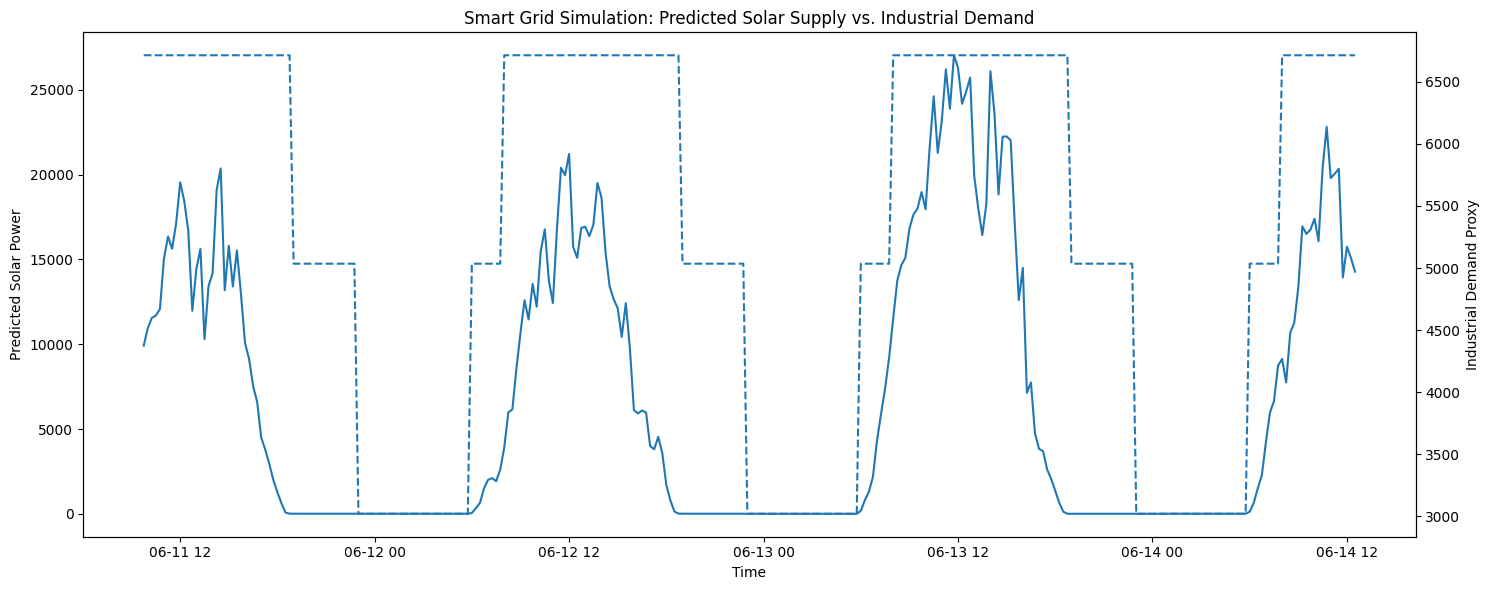

In [69]:
sample_simulation = simulation_df.iloc[:300]

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.set_xlabel("Time")
ax1.set_ylabel("Predicted Solar Power")
ax1.plot(
    sample_simulation["DATE_TIME"],
    sample_simulation["Predicted Solar Power"],
    label="Predicted Solar Power"
)
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.set_ylabel("Industrial Demand Proxy")
ax2.plot(
    sample_simulation["DATE_TIME"],
    sample_simulation["Industrial Demand Proxy"],
    linestyle="--",
    label="Industrial Demand Proxy"
)
ax2.tick_params(axis="y")

plt.title("Smart Grid Simulation: Predicted Solar Supply vs. Industrial Demand")
fig.tight_layout()
plt.show()

,Condition,Count
0,Insufficient Solar Supply,396
1,Sufficient Solar Supply,235


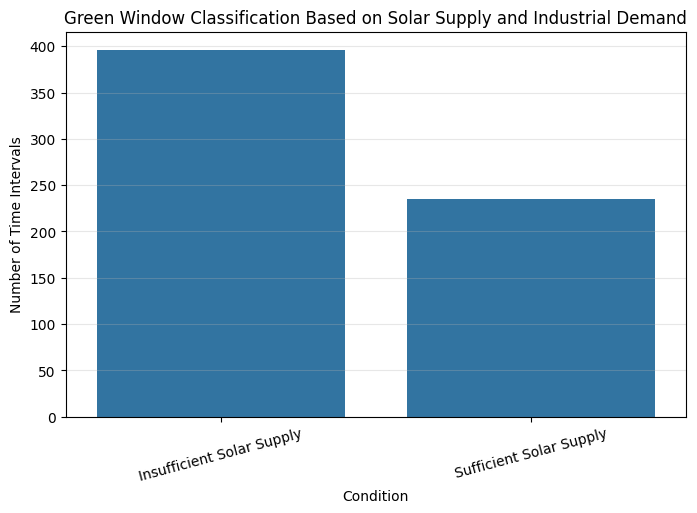

In [70]:
green_window_counts = simulation_df["Green Window"].value_counts().reset_index()
green_window_counts.columns = ["Condition", "Count"]

display(green_window_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=green_window_counts, x="Condition", y="Count")
plt.title("Green Window Classification Based on Solar Supply and Industrial Demand")
plt.xlabel("Condition")
plt.ylabel("Number of Time Intervals")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()

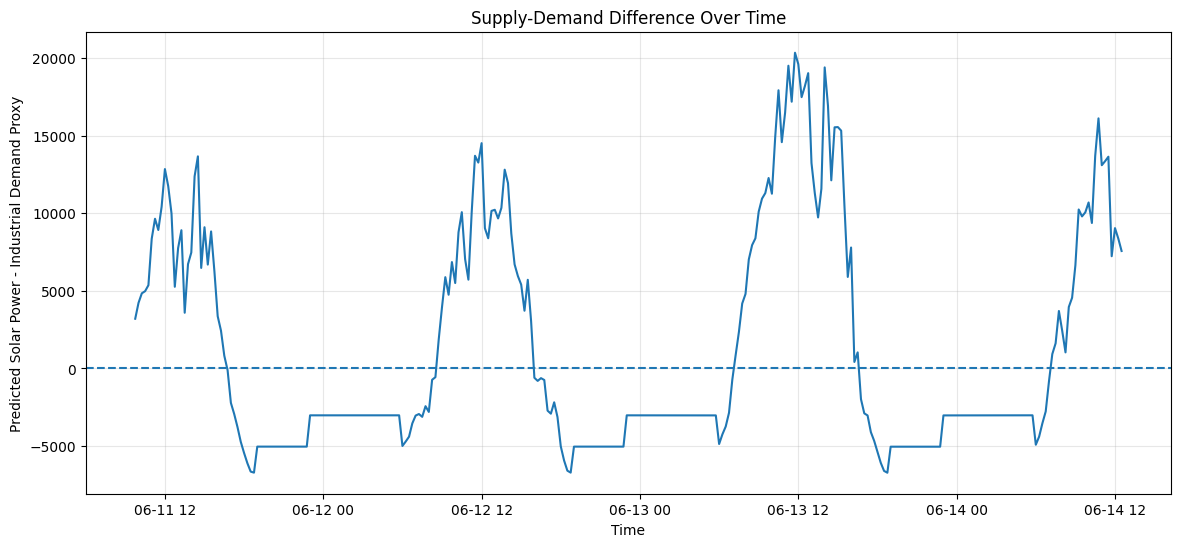

In [71]:
plt.figure(figsize=(14, 6))
plt.plot(
    simulation_df["DATE_TIME"].iloc[:300],
    simulation_df["Supply Demand Difference"].iloc[:300]
)
plt.axhline(y=0, linestyle="--")
plt.title("Supply-Demand Difference Over Time")
plt.xlabel("Time")
plt.ylabel("Predicted Solar Power - Industrial Demand Proxy")
plt.grid(alpha=0.3)
plt.show()

## 16. Test Submission Interpretation

The final model was applied to the unseen chronological test set and produced solar power predictions based on weather, time-series, and demand-related features. The actual vs. predicted graph shows how closely the final model follows the real AC power trend.

The smart grid simulation compares predicted solar generation with the industrial demand proxy. Time intervals where predicted solar generation is greater than or equal to the industrial demand proxy are interpreted as green windows. These windows represent periods where renewable generation can potentially support industrial electricity consumption.

However, the industrial demand variable is a proxy rather than real factory load data. Therefore, the green window analysis should be interpreted as a simulated decision-support framework rather than a fully deployed industrial energy management system.

## 17. Code Implementation Summary

The implementation process in Part B included selecting the final tuned XGBoost model, applying it to the chronological test set, calculating test metrics, visualizing actual and predicted power values, and comparing predicted solar generation with the industrial demand proxy.

The main Python libraries used in this section were pandas, NumPy, scikit-learn, XGBoost, matplotlib, and seaborn.

# PART C – DEPLOYMENT

This section explains how the final forecasting model can be prepared for deployment. The deployment process includes model serialization, model serving, API integration, security considerations, and monitoring/logging.

The purpose of this section is not to build a full industrial software system, but to show how the trained machine learning model could be integrated into a real smart grid decision-support environment.

## 18. Model Serialization

Model serialization allows the trained machine learning model to be saved as a file and reused later without retraining. In this project, the final tuned XGBoost model was saved using `joblib`.

This step is important for deployment because the model can be loaded by another application, API, or monitoring system to generate new solar power forecasts.

In [72]:
joblib.dump(final_model, "solar_power_forecasting_model.pkl")

print("Model saved successfully as solar_power_forecasting_model.pkl")

Model saved successfully as solar_power_forecasting_model.pkl


In [73]:
loaded_model = joblib.load("solar_power_forecasting_model.pkl")

sample_input = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample_input)

print("Sample input:")
display(sample_input)

print("Sample Prediction:", sample_prediction[0])

Sample input:


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,temp_diff,industrial_demand_proxy,hour,dayofweek,month,power_lag_1h
2522,24.623517,34.098657,0.308279,9.475141,6713.336503,9,3,6,7359.114286


Sample Prediction: 9916.271


## 19. Model Serving and API Integration

For deployment, the trained model can be served through a REST API using frameworks such as Flask or FastAPI. In a real smart grid environment, sensor data such as irradiation, ambient temperature, module temperature, time information, lag-based power output, and industrial demand proxy values would be sent to the API.

The API would apply the same preprocessing and feature engineering steps used during training, load the serialized model file, generate a solar power prediction, and return the predicted value to the grid management system.

A possible API workflow is:

1. Receive real-time sensor data.
2. Apply the same feature engineering steps used in the training notebook.
3. Load the serialized model file.
4. Generate solar power prediction.
5. Return the predicted solar output to the energy management system.

In [74]:
def predict_solar_power(input_data):
    """
    Example prediction function for deployment.
    input_data must contain the same features used during model training.
    """
    input_df = pd.DataFrame([input_data])
    prediction = loaded_model.predict(input_df)
    return prediction[0]


example_input = {
    "AMBIENT_TEMPERATURE": X_test.iloc[0]["AMBIENT_TEMPERATURE"],
    "MODULE_TEMPERATURE": X_test.iloc[0]["MODULE_TEMPERATURE"],
    "IRRADIATION": X_test.iloc[0]["IRRADIATION"],
    "temp_diff": X_test.iloc[0]["temp_diff"],
    "industrial_demand_proxy": X_test.iloc[0]["industrial_demand_proxy"],
    "hour": X_test.iloc[0]["hour"],
    "dayofweek": X_test.iloc[0]["dayofweek"],
    "month": X_test.iloc[0]["month"],
    "power_lag_1h": X_test.iloc[0]["power_lag_1h"]
}

api_style_prediction = predict_solar_power(example_input)

print("API-style input:")
display(pd.DataFrame([example_input]))

print("API-style prediction:", api_style_prediction)

API-style input:


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,temp_diff,industrial_demand_proxy,hour,dayofweek,month,power_lag_1h
0,24.623517,34.098657,0.308279,9.475141,6713.336503,9.0,3.0,6.0,7359.114286


API-style prediction: 9916.271


## 20. Example API Structure

The following pseudo-code shows how the model could be served using a simple API structure. This is provided as a deployment design example rather than a full production system.

```python
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()
model = joblib.load("solar_power_forecasting_model.pkl")

@app.post("/predict")
def predict(input_data: dict):
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df)
    return {"predicted_solar_power": float(prediction[0])}


```markdown
## 21. Security Considerations

In a real deployment environment, API access should be protected through authentication and authorization mechanisms. Sensor data should be transmitted through secure communication protocols such as HTTPS. Input validation is necessary to prevent incorrect or malicious data from affecting the prediction system.

Since energy forecasting can influence grid decisions, access logs, user permissions, and system-level monitoring should be carefully managed. Only authorized users or systems should be able to send prediction requests or access forecasting results.

## 22. Monitoring and Logging

After deployment, the model should be monitored continuously. Prediction errors should be logged by comparing predicted solar output with actual measured values. If model performance decreases over time, this may indicate data drift caused by seasonal changes, sensor degradation, or changes in industrial demand patterns.

Important values to monitor include:

- Prediction timestamp
- Input sensor values
- Predicted solar power
- Actual solar power when available
- Prediction error
- API response time
- System errors or missing input values

If the model performance drops below an acceptable threshold, the model should be retrained with updated data.

In [75]:
monitoring_log = pd.DataFrame({
    "DATE_TIME": test_results["DATE_TIME"].iloc[:10].values,
    "Predicted Solar Power": test_results["Predicted AC Power"].iloc[:10].values,
    "Actual Solar Power": test_results["Actual AC Power"].iloc[:10].values
})

monitoring_log["Prediction Error"] = (
    monitoring_log["Actual Solar Power"] - monitoring_log["Predicted Solar Power"]
)

monitoring_log["Absolute Error"] = monitoring_log["Prediction Error"].abs()

display(monitoring_log)

,DATE_TIME,Predicted Solar Power,Actual Solar Power,Prediction Error,Absolute Error
0,2020-06-11 09:45:00,9916.271484,10287.671429,371.399944,371.399944
1,2020-06-11 10:00:00,10939.126953,11091.971429,152.844475,152.844475
2,2020-06-11 10:15:00,11552.998047,12068.066071,515.068025,515.068025
3,2020-06-11 10:30:00,11691.333008,12320.907143,629.574135,629.574135
4,2020-06-11 10:45:00,12075.508789,12771.435714,695.926925,695.926925
5,2020-06-11 11:00:00,15065.155273,15504.928571,439.773298,439.773298
6,2020-06-11 11:15:00,16353.753906,16784.860714,431.106808,431.106808
7,2020-06-11 11:30:00,15629.233398,15787.112500,157.879102,157.879102
8,2020-06-11 11:45:00,17122.876953,17764.082143,641.205190,641.205190
9,2020-06-11 12:00:00,19551.318359,19972.937500,421.619141,421.619141


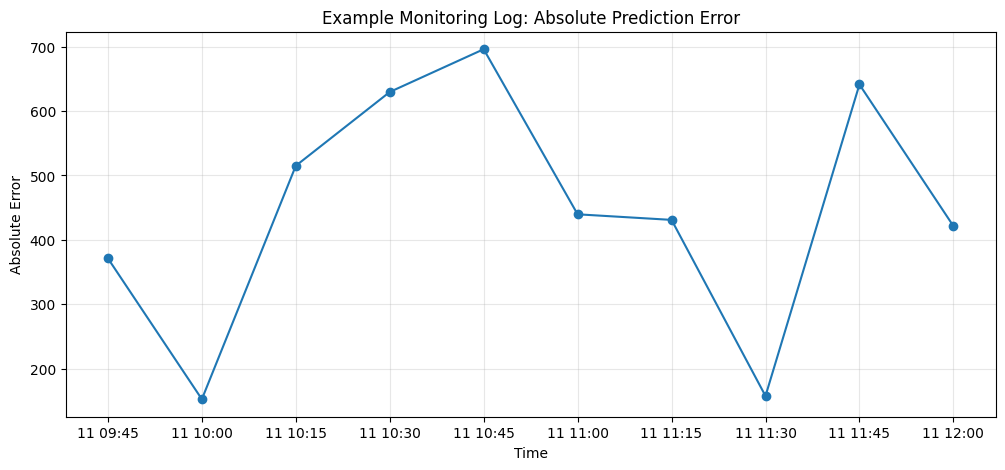

In [76]:
plt.figure(figsize=(12, 5))
plt.plot(monitoring_log["DATE_TIME"], monitoring_log["Absolute Error"], marker="o")
plt.title("Example Monitoring Log: Absolute Prediction Error")
plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.grid(alpha=0.3)
plt.show()

## 23. Deployment Summary

The deployment section demonstrates that the final tuned XGBoost model can be serialized, reloaded, and used for new predictions. The API-style prediction function shows how the model could receive input features and return a solar power forecast.

For real-world usage, the deployment system should include secure API access, input validation, continuous monitoring, error logging, and periodic model retraining. These steps are necessary to make the forecasting model reliable for smart grid decision-support applications.

# PART D – IN-CLASS PRESENTATION

This section summarizes the main points that will be presented in class. The presentation will focus on the project motivation, dataset structure, model refinement process, test results, smart grid simulation, and deployment plan.

The main goal of the presentation is to explain how AI-based solar power forecasting can support grid stability by combining renewable generation prediction with an industrial demand proxy.

## 24. Key Results for Presentation

The most important results to emphasize during the presentation are:

- The final model was trained using environmental variables, time-based features, lag features, and an industrial demand proxy.
- XGBoost was selected as the main forecasting model because it can capture non-linear relationships in structured data.
- Linear Regression and Random Forest were included as comparison models.
- Hyperparameter tuning and TimeSeriesSplit cross-validation were used to refine and validate the model.
- Feature importance analysis helped identify the most influential predictors.
- The smart grid simulation compared predicted solar supply with industrial demand proxy values.
- Green windows were used to identify time intervals where predicted solar generation could support industrial electricity demand.

## 25. Limitations

Although the model achieved strong predictive performance, several limitations should be considered. First, the industrial demand variable was used as a proxy rather than directly measured factory load data from the same physical site. Therefore, the supply-demand analysis should be interpreted as a simulated smart grid scenario.

Second, solar power generation is highly affected by sudden weather changes such as cloud cover, humidity, sensor noise, and unexpected irradiation fluctuations. These short-term variations may increase prediction errors during specific time intervals.

Third, the model was trained on historical data from a specific solar plant dataset. Its performance may change when applied to different seasons, geographical locations, or industrial consumption patterns.

## 26. Future Work

Future work can improve this project in several ways:

- Integrating directly measured factory load data instead of a simulated industrial demand proxy.
- Adding battery storage information to evaluate energy storage and load shifting strategies.
- Including additional weather variables such as humidity, wind speed, and cloud coverage.
- Testing the model on different solar plants and different seasons.
- Deploying the model as a real-time forecasting API connected to live sensor data.
- Creating a dashboard for monitoring solar prediction errors and green window availability.

# Conclusion

This project developed an AI-driven forecasting framework for predicting solar power generation using weather sensor data, engineered time-series features, and an industrial demand proxy. The model was refined through model comparison, hyperparameter tuning, time-series cross-validation, feature importance analysis, and residual error evaluation.

The integration of an industrial demand proxy allowed the project to move beyond standard solar forecasting and examine the relationship between renewable energy supply and industrial electricity demand. The test results and smart grid simulation show that machine learning can support short-term solar power forecasting and help identify periods when renewable energy can contribute to industrial load balancing.

The deployment section demonstrated how the final tuned XGBoost model can be serialized, reloaded, and used in an API-style prediction workflow. Security, monitoring, logging, and retraining considerations were also discussed to make the framework more suitable for real-world smart grid decision-support applications.

However, since the industrial demand data was used as a proxy, future work should include directly measured factory load data, battery storage information, and real-time grid consumption data. These additions would make the forecasting framework more realistic and applicable to industrial energy management.

# References

[1] T. Chen and C. Guestrin, “XGBoost: A Scalable Tree Boosting System,” in *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, San Francisco, CA, USA, 2016, pp. 785–794.

[2] F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[3] L. Breiman, “Random Forests,” *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001.

[4] J. D. Hunter, “Matplotlib: A 2D Graphics Environment,” *Computing in Science & Engineering*, vol. 9, no. 3, pp. 90–95, 2007.

[5] W. McKinney, “Data Structures for Statistical Computing in Python,” in *Proceedings of the 9th Python in Science Conference*, 2010, pp. 56–61.

[6] M. L. Waskom, “Seaborn: Statistical Data Visualization,” *Journal of Open Source Software*, vol. 6, no. 60, 2021.

[7] Google Colaboratory, “Google Colab,” Google Research, 2026. [Online]. Available: https://colab.research.google.com/

[8] Kaggle, “Solar Power Generation Data,” Kaggle Dataset, 2020. [Online]. Available: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data

[9] FastAPI, “FastAPI Documentation,” 2026. [Online]. Available: https://fastapi.tiangolo.com/

[10] Joblib Developers, “Joblib: Running Python Functions as Pipeline Jobs,” 2026. [Online]. Available: https://joblib.readthedocs.io/